In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:

data = pd.read_csv('spam.csv', encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
data.shape


(5572, 5)

In [11]:
data['Unnamed: 4'].value_counts()

Unnamed: 4
GNT:-)"                                                     2
 just Keep-in-touch\" gdeve.."                              1
 Never comfort me with a lie\" gud ni8 and sweet dreams"    1
 CALL 2MWEN IM BK FRMCLOUD 9! J X\""                        1
 one day these two will become FREINDS FOREVER!"            1
Name: count, dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


After dropping last 3 columns

In [14]:
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
data.rename(columns={'v1': 'target', 'v2':'text'},inplace=True)
data.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data['target']=encoder.fit_transform(data['target'])

spam  =1 ; NotSpam =0

In [23]:
data.isnull().sum()

target    0
text      0
dtype: int64

In [24]:
data = data.drop_duplicates(keep='first')
data.duplicated().sum()

np.int64(0)

In [25]:
data['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

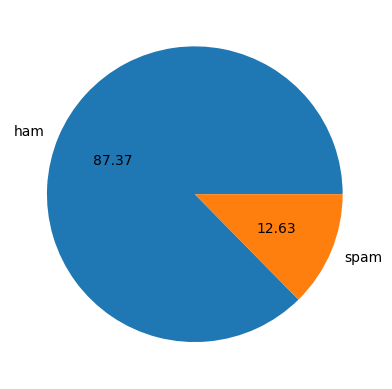

In [26]:
plt.pie(data['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [27]:
import nltk

In [31]:
data['num_characters']=data['text'].apply(len)
data.head()

C:\Users\rohan\AppData\Local\Temp\ipykernel_12692\1884697630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['num_characters']=data['text'].apply(len)


,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [38]:
import nltk
nltk.data.path.append(r'R:\Gen AI\myenvLLM\nltk_data')

In [40]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to r:\Gen
[nltk_data]     AI\myenvLLM\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [41]:
data['num_words']=data['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [42]:
data.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [43]:
data['num_sentences']=data['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
data.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


| Term | Meaning          |
| ---- | ---------------- |
| Mean | Average          |
| Std  | Spread/variation |
| Min  | Smallest value   |
| 25%  | Lower quarter    |
| 50%  | Middle (median)  |
| 75%  | Upper quarter    |
| Max  | Largest value    |


In [45]:
data[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


<Axes: xlabel='num_characters', ylabel='Count'>

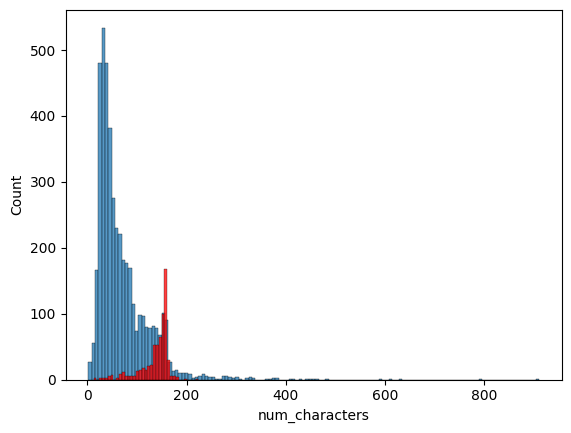

In [49]:
plt.Figure(figsize=(12,6))
sns.histplot(data[data['target']==0]['num_characters'])
sns.histplot(data[data['target']==1]['num_characters'],color='red')

<Axes: >

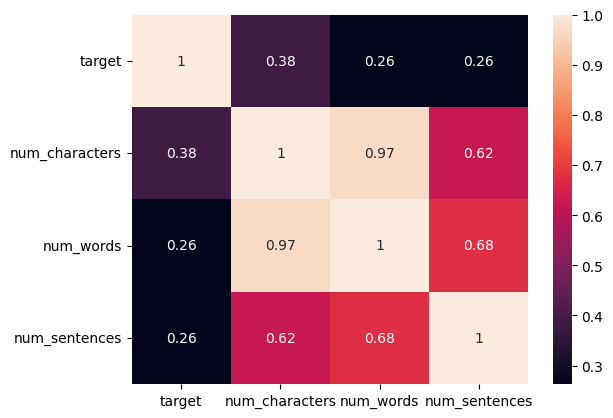

In [52]:
sns.heatmap(data[['target','num_characters','num_words','num_sentences']].corr(), annot=True)

Preprocessing
>lower case

>Tokenizing

>rm special char

>rm stop words, punctuation

>stemming


In [ ]:
from nltk.corpus import stopwords
stopwords.words('english') #they are words which dont add any meaning to sentence

In [62]:
import string
string.punctuation #same here , they dont add any value

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [76]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
# reduces words to its root form , ie for loving-love

In [72]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)    

    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [75]:
transform_text('What! are? you thinking of yourself huh?')

'think huh'

In [77]:
data['transformed_text'] = data['text'].apply(transform_text)
data.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
!pip install wordcloud

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

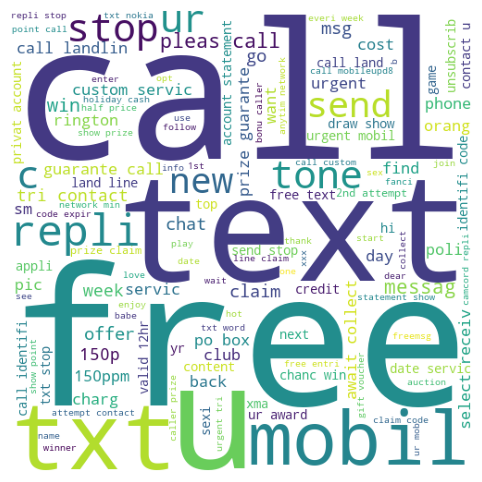

In [80]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc = wc.generate(data[data['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.axis('off')

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

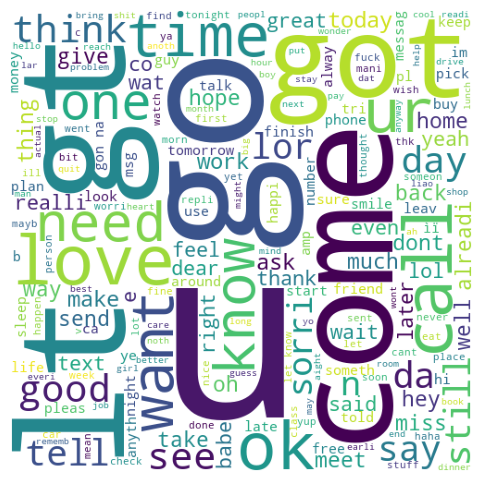

In [81]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
ham_wc = wc.generate(data[data['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)
plt.axis('off')

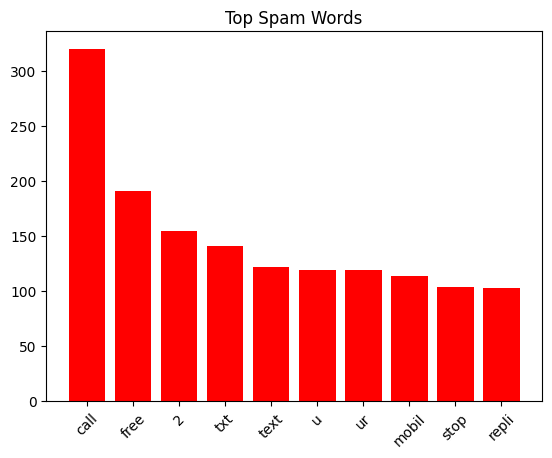

In [91]:
from collections import Counter
import matplotlib.pyplot as plt

# get top words
spam1 = Counter(" ".join(data[data['target']==1]['transformed_text']).split()).most_common(10)
ham1 = Counter(" ".join(data[data['target']==0]['transformed_text']).split()).most_common(10)

# separate words & counts
spam_words = [i[0] for i in spam1]
spam_counts = [i[1] for i in spam1]

# plot
plt.bar(spam_words, spam_counts, color='red')
plt.xticks(rotation=45)
plt.title("Top Spam Words")
plt.show()

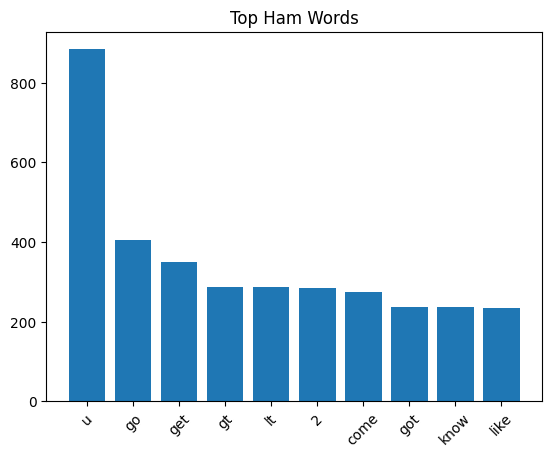

In [92]:
ham_words = [i[0] for i in ham1]
ham_counts = [i[1] for i in ham1]

plt.bar(ham_words, ham_counts)
plt.xticks(rotation=45)
plt.title("Top Ham Words")
plt.show()

In [93]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X = cv.fit_transform(data['transformed_text']).toarray()
X.shape

(5169, 6715)

In [95]:
y =data['target'].values
y.shape

(5169,)

In [96]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [97]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report   
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()



In [102]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print("GaussianNB Accuracy:",accuracy_score(y_test,y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))

print("Classification Report:\n", classification_report(y_test, y_pred1))

GaussianNB Accuracy: 0.8800773694390716
Confusion Matrix:
 [[871  25]
 [ 12 126]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.88      0.93       896
           1       0.53      0.86      0.66       138

    accuracy                           0.88      1034
   macro avg       0.75      0.87      0.79      1034
weighted avg       0.92      0.88      0.89      1034



In [101]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print("MultinomialNB Accuracy:",accuracy_score(y_test,y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("Classification Report:\n", classification_report(y_test, y_pred2))

MultinomialNB Accuracy: 0.9642166344294004
Confusion Matrix:
 [[871  25]
 [ 12 126]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       896
           1       0.83      0.91      0.87       138

    accuracy                           0.96      1034
   macro avg       0.91      0.94      0.93      1034
weighted avg       0.97      0.96      0.96      1034



In [103]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print("BernoulliNB Accuracy:",accuracy_score(y_test,y_pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("Classification Report:\n", classification_report(y_test, y_pred3))

BernoulliNB Accuracy: 0.9700193423597679
Confusion Matrix:
 [[893   3]
 [ 28 110]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       896
           1       0.97      0.80      0.88       138

    accuracy                           0.97      1034
   macro avg       0.97      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [104]:
data.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [185]:
import random

random_index = random.randint(0, len(data)-1)

sample_text = data['text'][random_index]
sample_clean = data['transformed_text'][random_index]

print("Original:", sample_text)
print("Cleaned:", sample_clean)

Original: No 1 POLYPHONIC tone 4 ur mob every week! Just txt PT2 to 87575. 1st Tone FREE ! so get txtin now and tell ur friends. 150p/tone. 16 reply HL 4info
Cleaned: 1 polyphon tone 4 ur mob everi week txt pt2 87575 1st tone free get txtin tell ur friend 16 repli hl 4info


In [178]:
vector_input = cv.transform([sample_clean]).toarray()

In [179]:
result = bnb.predict(vector_input)

if result[0] == 1:
    print("Prediction: SPAM ")
else:
    print("Prediction: Not SPAM ")

Prediction: SPAM 


In [154]:
msg = input("Enter message: ")

clean = transform_text(msg)

vector = cv.transform([clean]).toarray()

result = bnb.predict(vector)

if result[0] == 1:
    print("Spam ")
else:
    print("Not Spam ")

Spam 


In [148]:
pickle.dump((bnb, cv), open('model_bundle.pkl', 'wb'))